In [1]:
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
#path = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput_decayAncestor_Spectrum/'
#DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))
path = '/scratch/group/mitchcomp/CDMS/data/perry5334/SourceSimOutput_decayAncestor_Isotope/'
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))

In [3]:
det = 1
mczipFrame = CDataFrame(f"G4SimDir/mczip{det}", DMCfiles)
mcDecaysFrame = CDataFrame("G4SimDir/mcDecays", DMCfiles)

In [106]:
mczipGeActivEvents = np.unique(mczipFrame.Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])
mcDecaysGeActivEvents = np.unique(mcDecaysFrame.Filter(f'DetNum=={det}').Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])

In [107]:
branches = ['EventNum', 'PName', 'KE', 'Edep', 'Time1', 'Time3'] #, 'decayAncestor.PName', 'decayAncestor.Process']#, 
            #'decayAncestor.TrackID', 'decayAncestor.T', 'decayAncestor.VolName']

mcFluxCounterFrame = CDataFrame("G4SimDir/mcFluxCounter", DMCfiles)
mcFluxCounter = mcFluxCounterFrame.AsNumpy(branches + ['InOut'])

In [108]:
fourColors = ['blue', '#00BCBC', '#E59621', '#E50000']

(0.5176554274701426, 50000000.0)

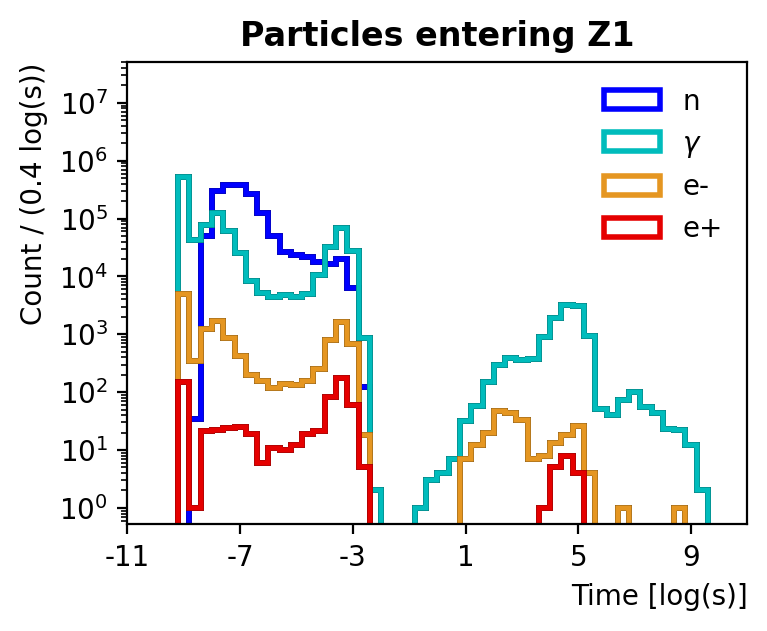

In [111]:
plt.figure(figsize=(4,3), dpi=200)
enterCut = mcFluxCounter['InOut'] == 1
Time_neutron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'neutron') & enterCut]*1e-9
Time_gamma = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'gamma') & enterCut]*1e-9
Time_electron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e-') & enterCut]*1e-9
Time_positron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e+') & enterCut]*1e-9
TimeBins = np.logspace(-10,10,51)

plt.hist(Time_neutron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_neutron, bins = TimeBins, label = 'n', histtype = 'step', lw = 2, color = fourColors[0])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, color = fourColors[1])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, color = fourColors[2])
plt.hist(Time_positron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_positron, bins = TimeBins, label = 'e+', histtype = 'step', lw = 2, color = fourColors[3])

plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.4 log(s))')
plt.title('Particles entering Z1', fontweight = 'bold')
plt.xscale('log')
plt.xticks([1e-11, 1e-7, 1e-3, 1e1, 1e5, 1e9], ['-11', '-7', '-3', '1', '5', '9'])
plt.yscale('log')
plt.legend()
plt.ylim(None, 5e7)

(0.5247782233010861, 50000000.0)

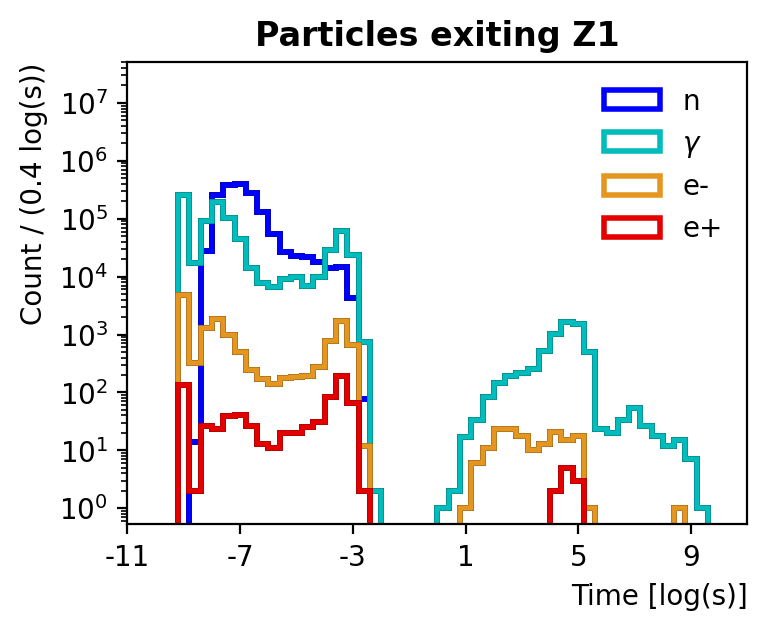

In [112]:
plt.figure(figsize=(4,3), dpi=200)
exitCut = mcFluxCounter['InOut'] == 2
Time_neutron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'neutron') & exitCut]*1e-9
Time_gamma = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'gamma') & exitCut]*1e-9
Time_electron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e-') & exitCut]*1e-9
Time_positron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e+') & exitCut]*1e-9
TimeBins = np.logspace(-10,10,51)

plt.hist(Time_neutron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_neutron, bins = TimeBins, label = 'n', histtype = 'step', lw = 2, color = fourColors[0])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, color = fourColors[1])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, color = fourColors[2])
plt.hist(Time_positron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_positron, bins = TimeBins, label = 'e+', histtype = 'step', lw = 2, color = fourColors[3])

plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.4 log(s))')
plt.title('Particles exiting Z1', fontweight = 'bold')
plt.xscale('log')
plt.xticks([1e-11, 1e-7, 1e-3, 1e1, 1e5, 1e9], ['-11', '-7', '-3', '1', '5', '9'])
plt.yscale('log')
plt.legend()
plt.ylim(None, 5e7)

In [4]:
path = '/scratch/group/mitchcomp/CDMS/data/perry5334/SourceSimOutput_decayAncestor_Isotope/'
branches = ['EventNum', 'Parent', 'PName', 'KE', 'Edep', 'Time1', 'Time3', 'X1', 'Y1', 'Z1']#, 'decayAncestor.PName', 'decayAncestor.Process']#, 
            #'decayAncestor.TrackID', 'decayAncestor.T', 'decayAncestor.VolName']
mczip1files = np.sort(glob.glob(path + f'mczip1/mczip1_GeActivation_ancestorGe71_??????.root'))
mcDecays1files = np.sort(glob.glob(path + f'mcDecays1/mcDecays1_GeActivation_ancestorGe71_??????.root'))

In [5]:
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))

In [6]:
det = 1
mczipFrame = CDataFrame(f"mczip{det}", mczip1files)
mcDecaysFrame = CDataFrame(f"mcDecays{det}", mcDecays1files)

In [7]:
mczip = mczipFrame.AsNumpy(branches)
mcDecays = mcDecaysFrame.AsNumpy(branches)

In [8]:
mcDecays_EvtParent = np.array([(event, parent) for event in np.unique(mcDecays['EventNum']) for parent in np.unique(mcDecays['Parent'][mcDecays['EventNum'] == event])])
mczip_EvtParent = np.array([(event, parent) for event in np.unique(mczip['EventNum']) for parent in np.unique(mczip['Parent'][mczip['EventNum'] == event])])

#mcDecays['KEsum'] = np.array([mcDecays['KE'][(mcDecays['Parent'] == parent) & (mcDecays['EventNum'] == event)].sum() for event, parent in mcDecays_EvtParent])
mcDecays['KEsum'] = np.array([mcDecays['KE'][mcDecays['EventNum'] == event].sum() for event in np.unique(mcDecays['EventNum'])])
#mczip['Edepsum'] = np.array([mczip['Edep'][(mczip['Parent'] == parent) & (mczip['EventNum'] == event)].sum() for event, parent in mczip_EvtParent])
mczip['Edepsum'] = np.array([mczip['Edep'][mczip['EventNum'] == event].sum() for event in np.unique(mczip['EventNum'])])

In [9]:
fourColors = ['blue', '#00BCBC', '#E59621', '#E50000']

(0.5978958160959664, 500000000.0)

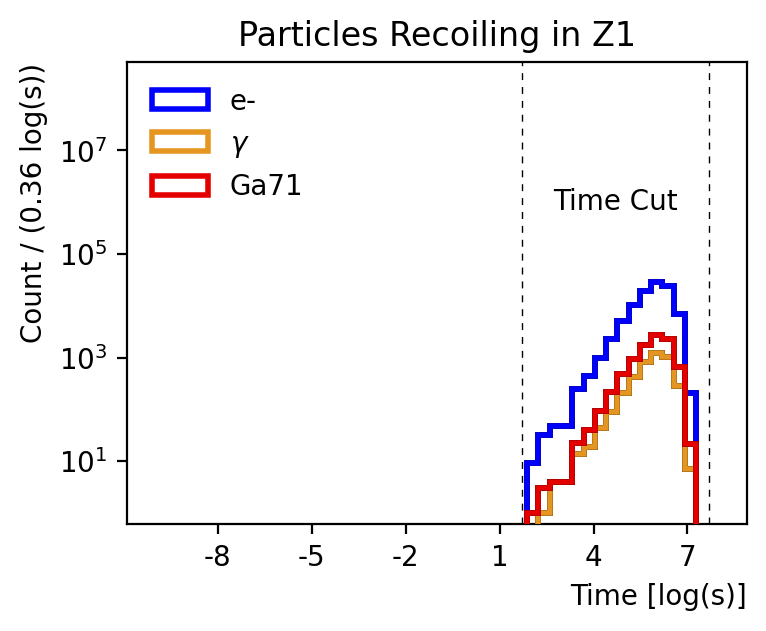

In [10]:
plt.figure(figsize=(4,3), dpi=200)
Time_electron = mczip['Time1'][mczip['PName'] == 'e-']*1e-9
Time_positron = mczip['Time1'][mczip['PName'] == 'e+']*1e-9
Time_gamma = mczip['Time1'][mczip['PName'] == 'gamma']*1e-9
Time_Ga71 = mczip['Time1'][mczip['PName'] == 'Ga71']*1e-9
TimeBins = np.logspace(-10,8, 51)

plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, zorder = 1, color = fourColors[0])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 0)
#plt.hist(Time_positron, bins = TimeBins, label = 'e+', histtype = 'step', lw = 2, zorder = 3, color = fourColors[1])
#plt.hist(Time_positron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 2)
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, zorder = 5, color = fourColors[2])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 4)
plt.hist(Time_Ga71, bins = TimeBins, label = 'Ga71', histtype = 'step', lw = 2, zorder = 7, color = fourColors[3])
plt.hist(Time_Ga71, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 6)

plt.axvline(5e1, 0, 1, lw = 0.5, ls = (0, (5, 5)), color = 'black')
plt.axvline(5e7, 0, 1, lw = 0.5, ls = (0, (5, 5)), color = 'black')
plt.text(5e4, 1e6, 'Time Cut', ha = 'center', va = 'center', fontstretch='extra-expanded', weight = 550)

plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.36 log(s))')
plt.title('Particles Recoiling in Z1')
plt.xscale('log')
plt.xticks([1e-8, 1e-5, 1e-2, 1e1, 1e4, 1e7], ['-8', '-5', '-2', '1', '4', '7'])
plt.yscale('log')
plt.legend(loc = 'upper left')
plt.ylim(None, 5e8)

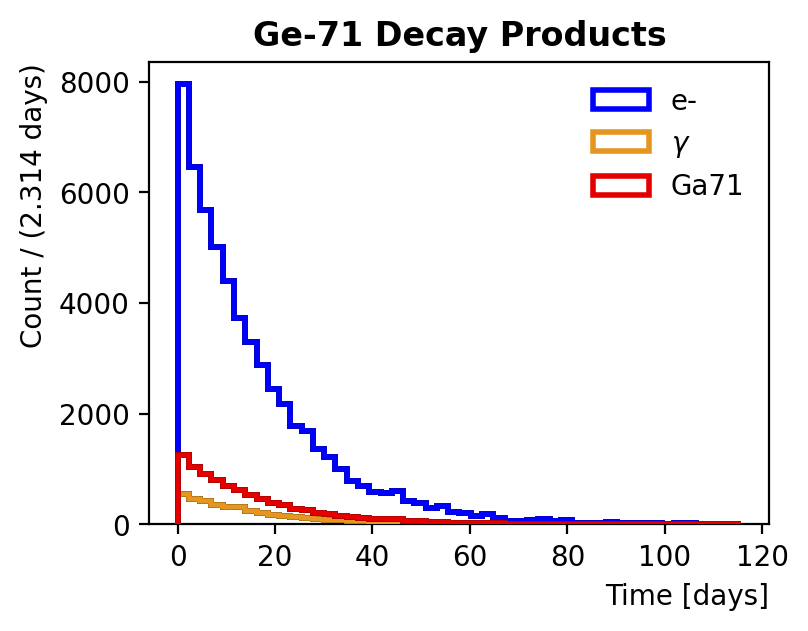

In [11]:
plt.figure(figsize=(4,3), dpi=200)
s2day = 1.157e-5
Time_electron = mcDecays['Time1'][mcDecays['PName'] == 'e-']*1e-9*s2day
Time_positron = mcDecays['Time1'][mcDecays['PName'] == 'e+']*1e-9*s2day
Time_gamma = mcDecays['Time1'][mcDecays['PName'] == 'gamma']*1e-9*s2day
Time_Ga71 = mcDecays['Time1'][mcDecays['PName'] == 'Ga71']*1e-9*s2day
TimeBins = np.linspace(0,1e7*s2day, 51)

plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, zorder = 1, color = fourColors[0])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 0)
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, zorder = 5, color = fourColors[2])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 4)
plt.hist(Time_Ga71, bins = TimeBins, label = 'Ga71', histtype = 'step', lw = 2, zorder = 7, color = fourColors[3])
plt.hist(Time_Ga71, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 6)

plt.xlabel('Time [days]')
plt.ylabel('Count / (2.314 days)')
plt.title('Ge-71 Decay Products', fontweight = 'bold')
#plt.yscale('log')
plt.legend(loc = 'upper right')
#plt.ylim(None, 150)

In [12]:
def func(x, a, b):
    return a*x + b

In [13]:
from scipy.optimize import curve_fit

counts_Ga71, bin_edges = np.histogram(Time_Ga71, bins = TimeBins)
bin_centers = bin_edges[:-1] + np.diff(TimeBins)[0] / 2

popt, pcov = curve_fit(func, bin_centers[:-7], np.log(counts_Ga71[:-7]), sigma=np.sqrt(counts_Ga71[:-7]) / counts_Ga71[:-7], absolute_sigma=True)

/tmp/job.15217200/ipykernel_3814985/3495701624.py:9: RuntimeWarning: divide by zero encountered in log
  plt.scatter(bin_centers, np.log(counts_e), s = 1, color = fourColors[0], label = 'e-')
/tmp/job.15217200/ipykernel_3814985/3495701624.py:10: RuntimeWarning: divide by zero encountered in log
  plt.errorbar(bin_centers, np.log(counts_e), yerr = np.sqrt(counts_e) / counts_e, ls = "None", color=fourColors[0], capsize = 1.5, elinewidth=0.2, capthick = 0.2)
/tmp/job.15217200/ipykernel_3814985/3495701624.py:10: RuntimeWarning: invalid value encountered in divide
  plt.errorbar(bin_centers, np.log(counts_e), yerr = np.sqrt(counts_e) / counts_e, ls = "None", color=fourColors[0], capsize = 1.5, elinewidth=0.2, capthick = 0.2)
/tmp/job.15217200/ipykernel_3814985/3495701624.py:12: RuntimeWarning: divide by zero encountered in log
  plt.scatter(bin_centers, np.log(counts_gamma), s = 1, color = fourColors[2], label = r'$\gamma$')
/tmp/job.15217200/ipykernel_3814985/3495701624.py:13: RuntimeWarni

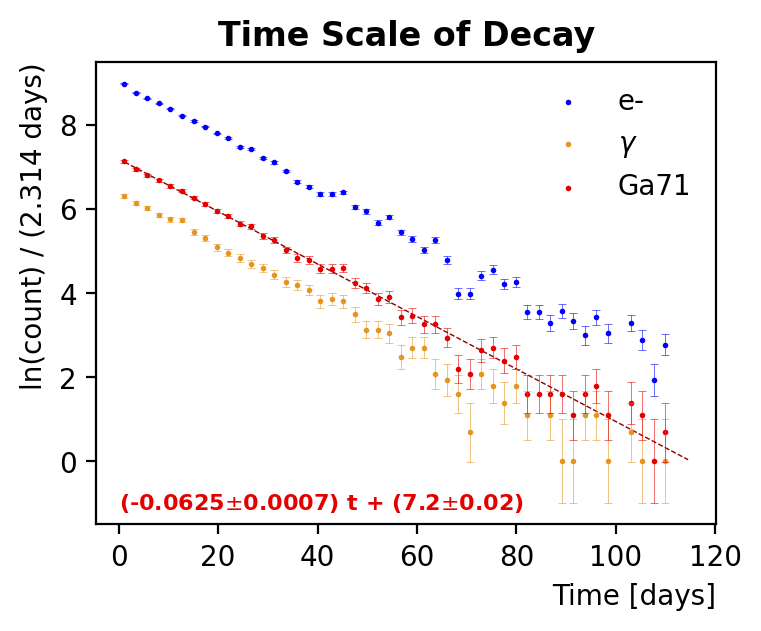

In [14]:
counts_e, bin_edges = np.histogram(Time_electron, bins = TimeBins)
counts_gamma, _ = np.histogram(Time_gamma, bins = TimeBins)
counts_Ga71, _ = np.histogram(Time_Ga71, bins = TimeBins)

bin_centers = bin_edges[:-1] + np.diff(TimeBins)[0] / 2

plt.figure(figsize=(4,3), dpi=200)

plt.scatter(bin_centers, np.log(counts_e), s = 1, color = fourColors[0], label = 'e-')
plt.errorbar(bin_centers, np.log(counts_e), yerr = np.sqrt(counts_e) / counts_e, ls = "None", color=fourColors[0], capsize = 1.5, elinewidth=0.2, capthick = 0.2)

plt.scatter(bin_centers, np.log(counts_gamma), s = 1, color = fourColors[2], label = r'$\gamma$')
plt.errorbar(bin_centers, np.log(counts_gamma), yerr = np.sqrt(counts_gamma) / counts_gamma, ls = "None", color=fourColors[2], capsize = 1.5, elinewidth=0.2, capthick = 0.2)

plt.scatter(bin_centers, np.log(counts_Ga71), s = 1, color = fourColors[3], label = 'Ga71')
plt.errorbar(bin_centers, np.log(counts_Ga71), yerr = np.sqrt(counts_Ga71) / counts_Ga71, ls = "None", color=fourColors[3], capsize = 1.5, elinewidth=0.2, capthick = 0.2)
plt.plot(bin_centers, func(bin_centers, popt[0], popt[1]), color = 'darkred', zorder=-1, lw = 0.5, ls = '--') 
         #label = f'({popt[0]:.3}' + r'$\pm$' + f'{np.sqrt(pcov[0][0]):.1}) t + ({popt[1]:.3}' + r'$\pm$' + f'{np.sqrt(pcov[1][1]):.1})')

plt.text(0, -1, f'({popt[0]:.3}' + r'$\pm$' + f'{np.sqrt(pcov[0][0]):.1}) t + ({popt[1]:.3}' + r'$\pm$' + f'{np.sqrt(pcov[1][1]):.1})', 
         va = 'center', ha = 'left', fontsize = 8, color = fourColors[3], fontweight = 'bold')

plt.xlabel('Time [days]')
plt.ylabel('ln(count) / (2.314 days)')
plt.title('Time Scale of Decay', fontweight = 'bold')
#plt.yscale('log')
plt.legend()
#plt.ylim(None, 150)

Text(0.5, 1.0, 'Total Recoil Energy / Event')

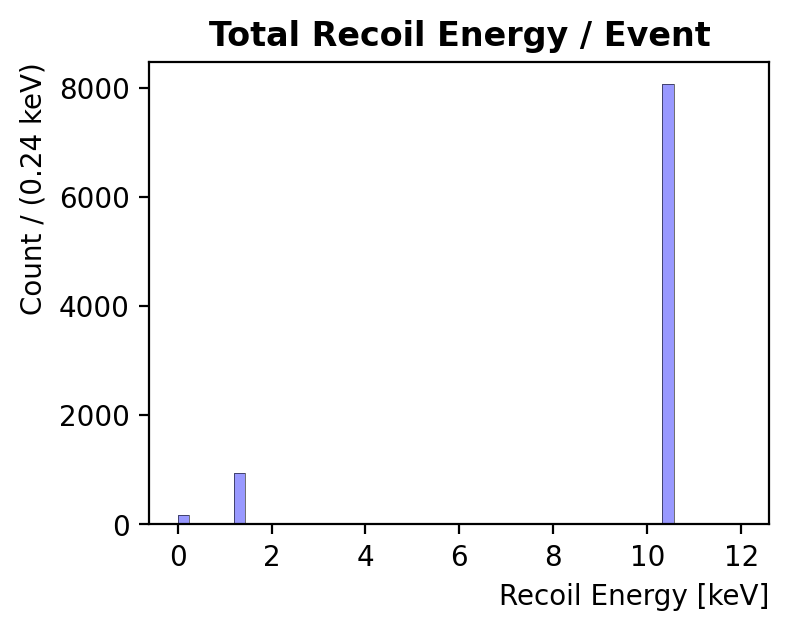

In [15]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, np.linspace(0, 12, 51), alpha = 0.4, color = 'blue')
plt.hist(mczip['Edepsum']*1e-3, np.linspace(0, 12, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Recoil Energy [keV]')
plt.ylabel('Count / (0.24 keV)')
plt.title(r'Total Recoil Energy / Event', fontweight = 'bold')
#plt.yscale('log')

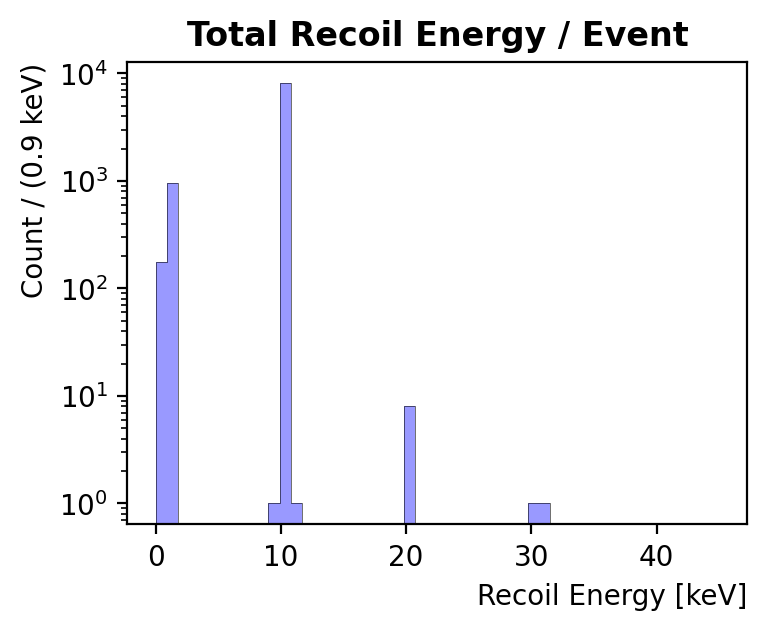

In [16]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 45, 51), alpha = 0.4, color = 'blue')
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 45, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Recoil Energy [keV]')
plt.ylabel('Count / (0.9 keV)')
plt.title('Total Recoil Energy / Event', fontweight = 'bold')
plt.yscale('log')

Text(0.5, 1.0, 'Total Decay Energy / Event')

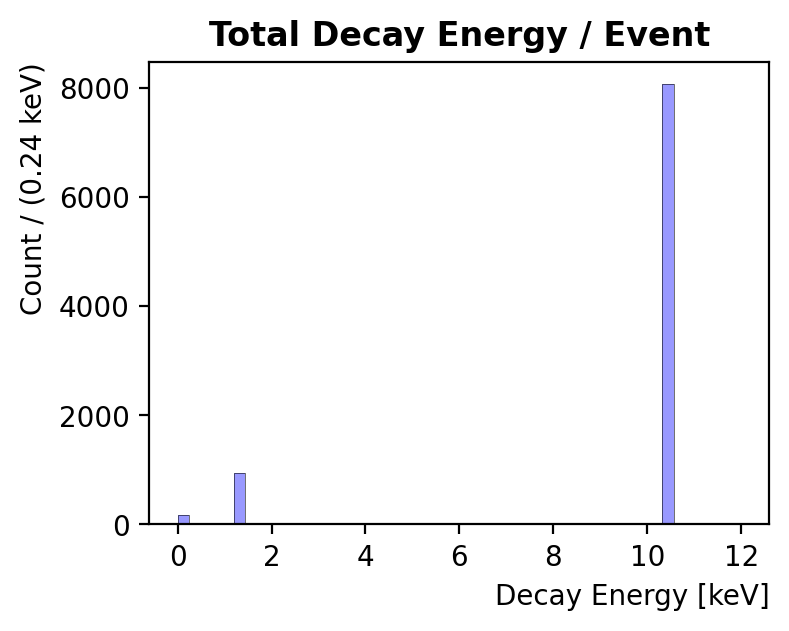

In [17]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3,  bins = np.linspace(0, 12, 51), alpha = 0.4, color = 'blue')
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.24 keV)')
plt.title('Total Decay Energy / Event', fontweight = 'bold')
#plt.yscale('log')

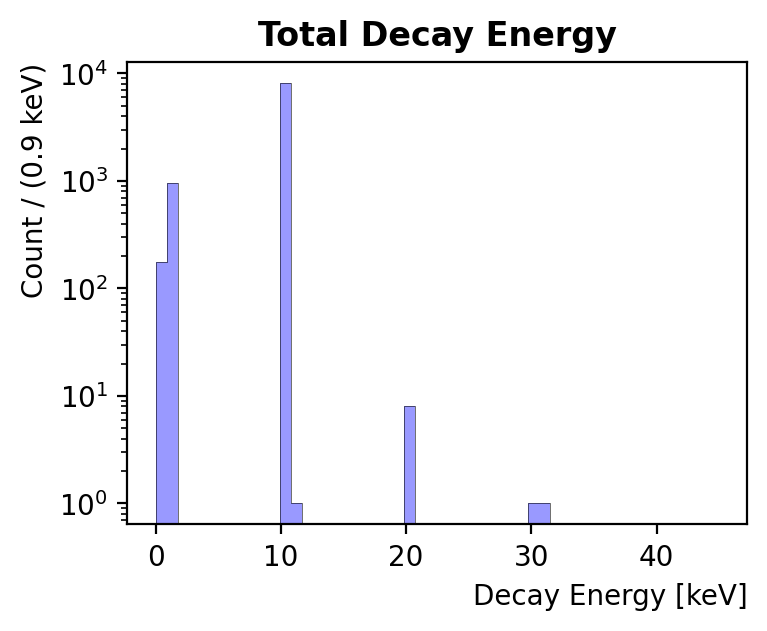

In [18]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 45, 51), alpha = 0.4, color = 'blue')
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 45, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.9 keV)')
plt.title('Total Decay Energy', fontweight = 'bold')
plt.yscale('log')

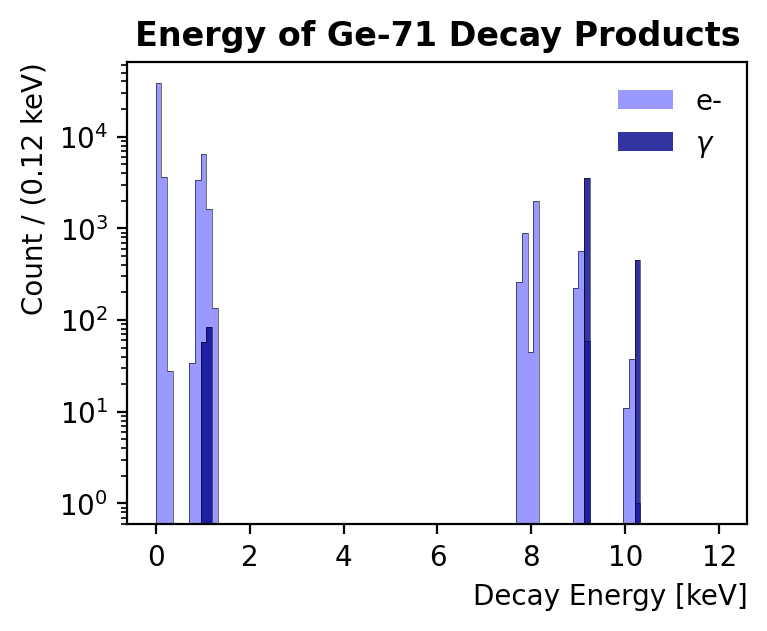

In [19]:
plt.figure(figsize=(4,3), dpi=200)
#bins = 50
bins = np.linspace(0, 12, 101)

plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = bins, alpha = 0.4, zorder = 0, label = 'e-', color = 'blue')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = bins, histtype='step', color = 'black', lw = 0.2, zorder = 1)
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = bins, alpha = 0.8, zorder = 2, label = r'$\gamma$', color = 'darkblue')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = bins, histtype='step', color = 'black', lw = 0.2, zorder = 3)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.12 keV)')
plt.title('Energy of Ge-71 Decay Products', fontweight='bold')
plt.yscale('log')
plt.legend(loc = 'upper right')

Text(0.5, 1.0, 'Decay and Recoil Energy Difference / Event')

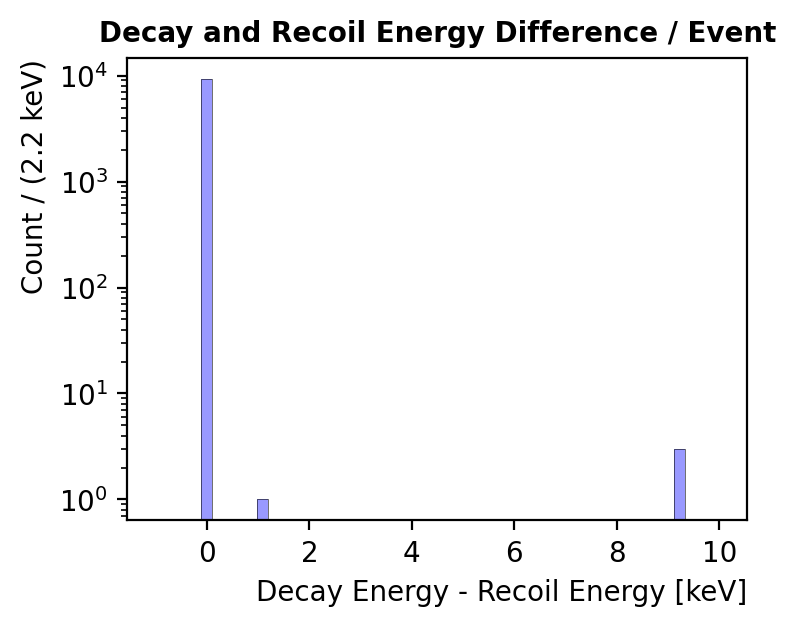

In [20]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3,  bins = np.linspace(-1, 10, 51), alpha = 0.4, color = 'blue')
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3, bins = np.linspace(-1, 10, 51), histtype='step', color = 'black', lw = 0.2)

plt.yscale('log')
plt.xlabel('Decay Energy - Recoil Energy [keV]')
plt.ylabel('Count / (2.2 keV)')
plt.title('Decay and Recoil Energy Difference / Event', fontweight = 'bold', fontsize = 10)

In [21]:
Ga71cut = mcDecays['PName'] == 'Ga71'

Text(0, 1, 'Count / (2 mm)')

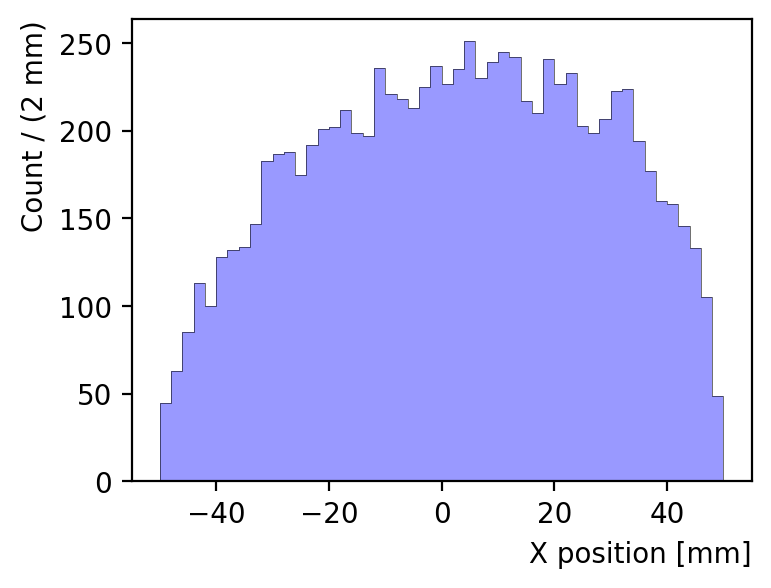

In [22]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['X1'][Ga71cut]*1e3,  bins = np.linspace(-50, 50, 51), alpha = 0.4, color = 'blue')
plt.hist(mcDecays['X1'][Ga71cut]*1e3,  bins = np.linspace(-50, 50, 51), histtype='step', color = 'black', lw = 0.2)
plt.xlabel('X position [mm]')
plt.ylabel('Count / (2 mm)')

Text(0, 1, 'Count / (2 mm)')

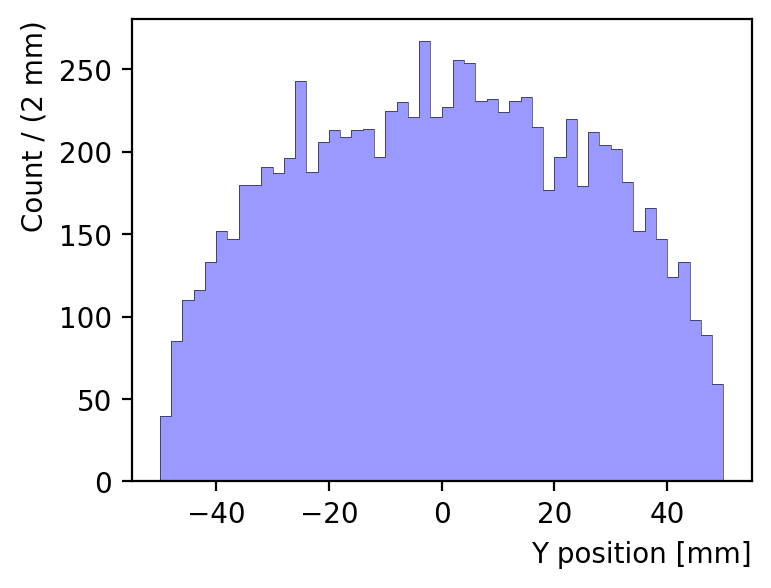

In [23]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['Y1'][Ga71cut]*1e3,  bins = np.linspace(-50, 50, 51), alpha = 0.4, color = 'blue')
plt.hist(mcDecays['Y1'][Ga71cut]*1e3,  bins = np.linspace(-50, 50, 51), histtype='step', color = 'black', lw = 0.2)
plt.xlabel('Y position [mm]')
plt.ylabel('Count / (2 mm)')

Text(0, 1, 'Count / (2 mm)')

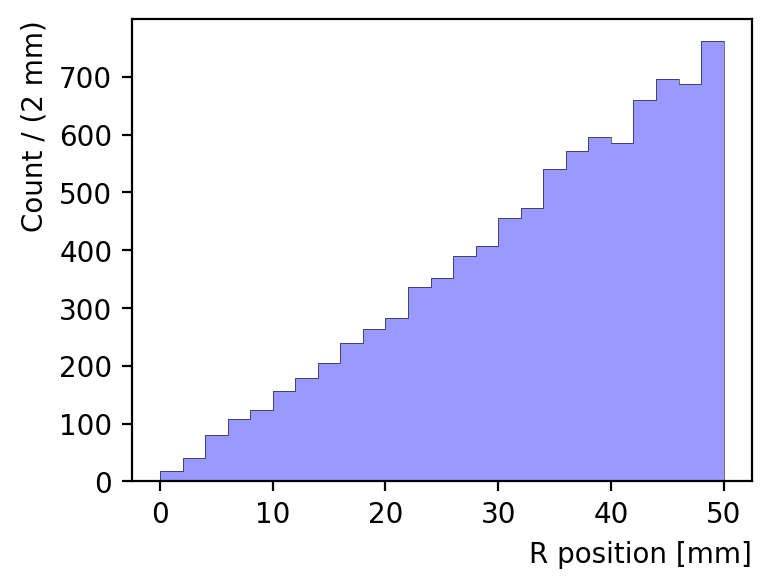

In [24]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(np.sqrt(mcDecays['X1'][Ga71cut]**2 + mcDecays['Y1'][Ga71cut]**2)*1e3,  bins = np.linspace(0, 50, 26), alpha = 0.4, color = 'blue')
plt.hist(np.sqrt(mcDecays['X1'][Ga71cut]**2 + mcDecays['Y1'][Ga71cut]**2)*1e3,  bins = np.linspace(0, 50, 26), histtype='step', color = 'black', lw = 0.2)
plt.xlabel('R position [mm]')
plt.ylabel('Count / (2 mm)')

In [25]:
path = '/scratch/group/mitchcomp/CDMS/data/perry5334/SourceSimOutput_decayAncestor_Isotope/Cf252_vacuum/'
branches = ['EventNum', 'PName', 'KE', 'Edep', 'Time1', 'Time3']#, 'decayAncestor.PName', 'decayAncestor.Process']#, 
            #'decayAncestor.TrackID', 'decayAncestor.T', 'decayAncestor.VolName']
mcDecaysfiles = np.sort(glob.glob(path + f'Cf252_00250116_000000.root'))

In [26]:
mcDecaysFrame = CDataFrame(f"G4SimDir/mcDecays", mcDecaysfiles)
FissionEvents = np.unique(mcDecaysFrame.Filter('string(PName.data()) == "neutron"').AsNumpy(['EventNum'])['EventNum'])
mcDecays = mcDecaysFrame.AsNumpy(branches)

In [27]:
fourColors = ['blue', '#00BCBC', '#E59621', '#E50000']

In [28]:
eventMask = np.isin(mcDecays['EventNum'], FissionEvents)

In [29]:
#PNames = {event: mcDecays['PName'][mcDecays['EventNum'] == event] for event in np.unique(mcDecays['EventNum'])}
#KEs = {event: mcDecays['KE'][mcDecays['EventNum'] == event] for event in np.unique(mcDecays['EventNum'])}
PNamesFission = {event: mcDecays['PName'][mcDecays['EventNum'] == event] for event in FissionEvents}

In [30]:
n_emitted = np.zeros(len(list(PNamesFission.keys())))
for i, event in enumerate(list(PNamesFission.keys())):
    n_emitted[i] = PNamesFission[event].tolist().count('neutron')

(0.0, 9.0)

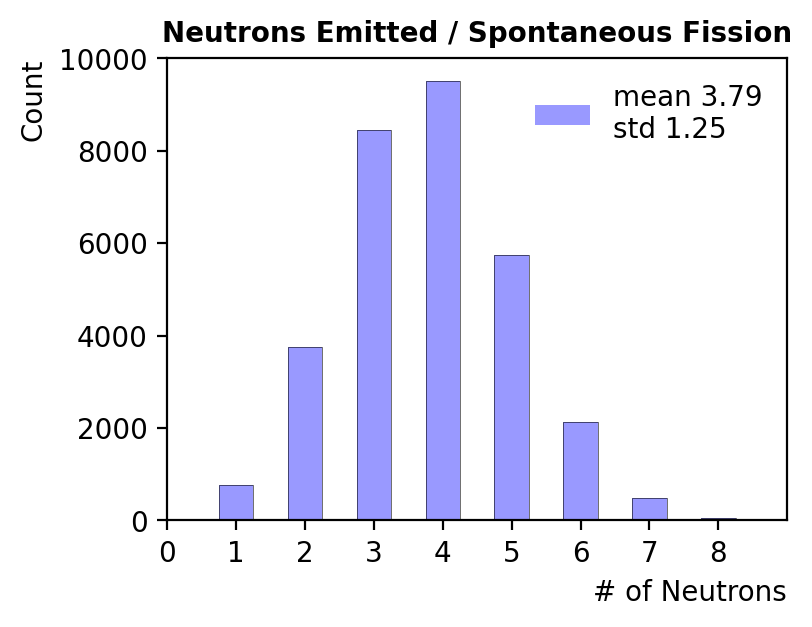

In [31]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(n_emitted,  bins = np.arange(-0.75, 9.25, 0.5), label = f'mean {np.mean(n_emitted):.3}' + '\n' + f'std {np.std(n_emitted):.3}', color = 'blue', alpha = 0.4)
plt.hist(n_emitted,  bins = np.arange(-0.75, 9.25, 0.5), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('# of Neutrons')
plt.ylabel('Count')
plt.title('Neutrons Emitted / Spontaneous Fission', fontweight = 'bold', fontsize = 10)
plt.legend()
plt.ylim(0, 10000)
plt.xticks(np.arange(0, 9, 1))
plt.xlim(0, 9)

(-0.15000000000000002, 3.0)

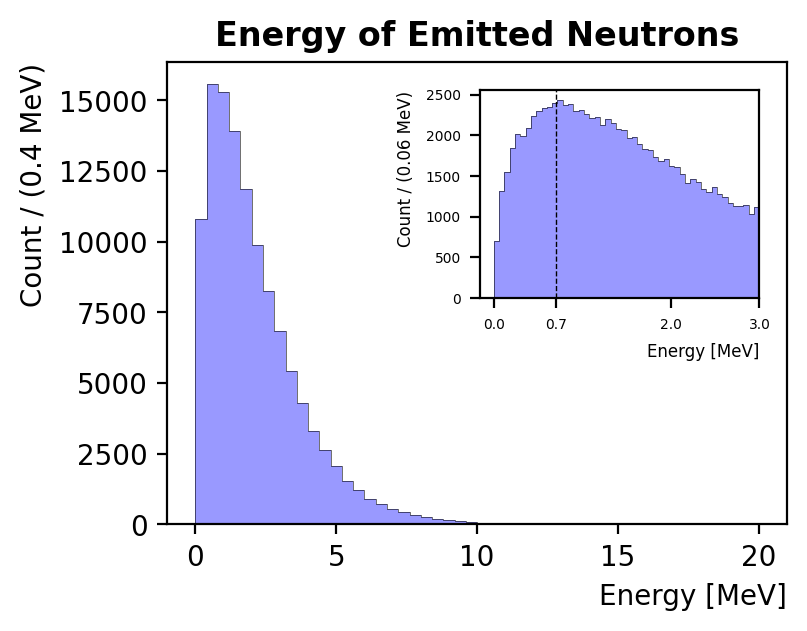

In [32]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(4,3), dpi=200)
KE_n = mcDecays['KE'][mcDecays['PName'] == 'neutron']*1e-6
bins = np.linspace(0, 20, 51)
binsInset = np.linspace(0, 3, 51)
    
# Plot the big plot first
ax.hist(KE_n,  bins = bins, color = 'blue', alpha = 0.4)
ax.hist(KE_n,  bins = bins, histtype='step', color = 'black', lw = 0.2)
    
ax.set_title('Energy of Emitted Neutrons', fontweight = 'bold')
ax.set_xlabel('Energy [MeV]')
ax.set_ylabel('Count / (0.4 MeV)')

# Create an inset of the zoomed-in plot
ax_inset = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)
ax_inset.hist(KE_n,  bins = binsInset, color = 'blue', alpha = 0.4)
ax_inset.hist(KE_n,  bins = binsInset, histtype='step', color = 'black', lw = 0.2)
ax_inset.axvline(0.7, 0, 1, lw = 0.5, ls = '--', color = 'black')
    
#ax_inset.set_title('Zoomed In')
ax_inset.set_xlabel('Energy [MeV]', fontsize = 6)
ax_inset.set_ylabel('Count / (0.06 MeV)', fontsize = 6)
ax_inset.tick_params(axis='both', which='major', labelsize=5)
ax_inset.set_xticks([0, 0.7, 2, 3])
ax_inset.set_xlim(None, 3)